In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- parâmetros físicos ---
eps = 1.0
mu = 1.0
c = 1 / np.sqrt(eps * mu)

# --- domínio ---
a = 0.5
Nx = Ny = 150
dx = dy = 2*a / Nx
cx, cy = Nx//2, Ny//2

dt = 0.4 / (c * np.sqrt(1/dx**2 + 1/dy**2))
Nt = 800

# --- campos ---
Ez = np.zeros((Nt, Nx, Ny))
Hx = np.zeros((Nt, Nx, Ny))
Hy = np.zeros((Nt, Nx, Ny))

for n in range(Nt-1):
    # --- fonte (pulso gaussiano no tempo) ---
    t0 = 50
    spread = 15
    source = np.exp(-((n - t0)**2) / spread**2)

    Ez[n, cx, cy] += source

    Hx[n+1, :, :-1] = Hx[n, :, :-1] - (dt/(mu*dy)) * (
        Ez[n, :, 1:] - Ez[n, :, :-1]
    )

    Hy[n+1, :-1, :] = Hy[n, :-1, :] + (dt/(mu*dx)) * (
        Ez[n, 1:, :] - Ez[n, :-1, :]
    )

    # --- Update E field (from H at time n+1) ---
    Ez[n+1, 1:-1, 1:-1] = Ez[n, 1:-1, 1:-1] + (dt/eps) * (
        (Hy[n+1, 1:-1, 1:-1] - Hy[n+1, :-2, 1:-1]) / dx -
        (Hx[n+1, 1:-1, 1:-1] - Hx[n+1, 1:-1, :-2]) / dy
    )


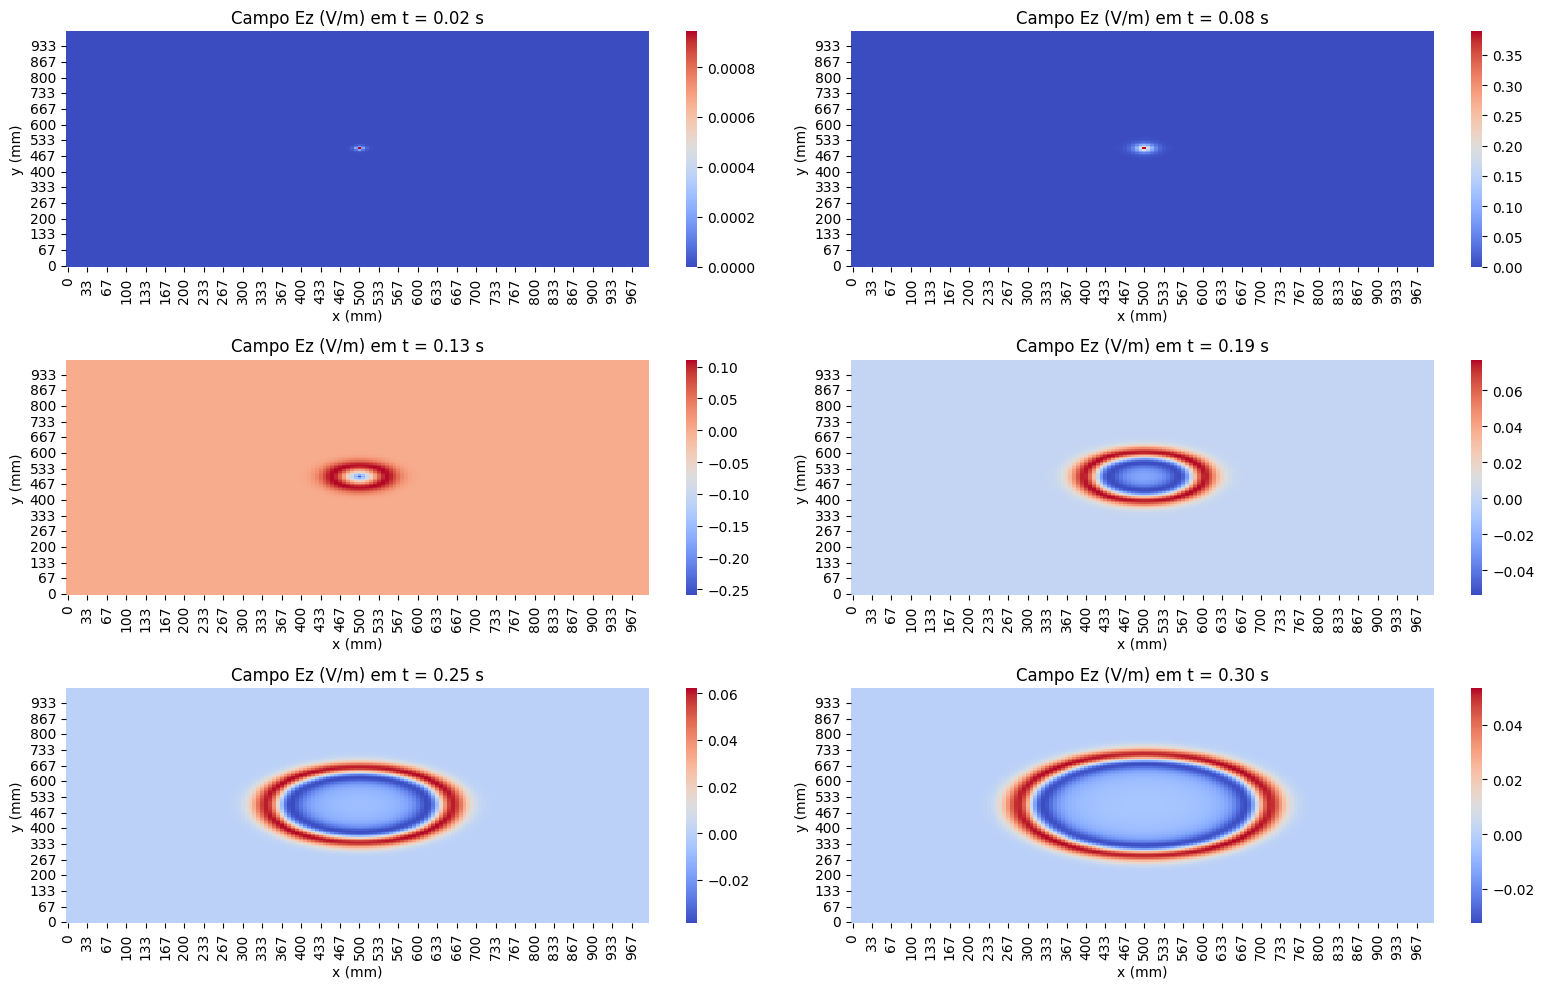

In [69]:
fig, axes = plt.subplots(3, 2, figsize=(16, 10))
t_list = [10, 40, 70, 100, 130, 160]

for i, ax in enumerate(axes.flat):
    sns.heatmap(Ez[t_list[i], :, :], ax=ax, annot=False, cmap='coolwarm')
    ax.set_xlabel("x (mm)")
    ax.set_ylabel("y (mm)")
    ax.set_title(f"Campo Ez (V/m) em t = {t_list[i]*dt:.2f} s")

    ticks_x = ax.get_xticks()
    labels_x = [f'{float(label.get_text()) * dx * 1000:.0f}' for label in ax.get_xticklabels()]
    ax.set_xticklabels(labels_x)

    ticks_y = ax.get_yticks()
    labels_y = [f'{float(label.get_text()) * dy * 1000:.0f}' for label in ax.get_yticklabels()]
    ax.set_yticklabels(labels_y)

    ax.invert_yaxis()

plt.tight_layout()
plt.show()